<a href="https://colab.research.google.com/github/meetj6897/Develop-LLM-from-scratch/blob/main/LLM_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tokneization and embedding

In [1]:
#getting the book from huggin face
import os
#taking the pdf from the local or huggingface
from datasets import load_dataset

ds = load_dataset("DarwinAnim8or/the-verdict")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


the-verdict.txt:   0%|          | 0.00/20.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/165 [00:00<?, ? examples/s]

##encode method (text to token)

In [2]:
text_book_list = ds['train']['text'][0:] # text data as a list
text_book_full = " ".join(text_book_list) # join all text into a single string

display(text_book_full[:500]) # Display the first 500 characters of the full text

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)  "The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\''

In [3]:
#tokenize all the character in the book and then give the token id to them
#actual llm have huge amount of the data
#so to make the otkne we have different librabry in earli we have NLTK now we are usingthe re (regular expression operation)

import re

text="hello my name is meet joshi. I am AI engineer."
result=re.split(r'(\s)',text) # spliting using the white space
print(result)

result=re.split(r'([,.:;?!_"()\\]|--|\s)',text) # spliting using the white space or , .
print(result)

#remove white space character so we loopoing over each result

result=[token for token in result if token!=' ']
print("removed whilte space",result)

#sould we remove the white space ?
"""
advantage is it reduces the memory requirements, while keeping them useful if we train models which is sensitive on the exact structure of the text
ex: if we are training them on python code then white space is imp as python sensitive to indentation and spacing

"""
#aply this to text of the book
token=re.split(r'([,.:;?!_"()\\]|--|\s)',text_book_full)
token_without_space=[token for token in token if token!=' ' and token!=''] # Removed empty strings that can result from split at boundaries
print(token_without_space[:5])

['hello', ' ', 'my', ' ', 'name', ' ', 'is', ' ', 'meet', ' ', 'joshi.', ' ', 'I', ' ', 'am', ' ', 'AI', ' ', 'engineer.']
['hello', ' ', 'my', ' ', 'name', ' ', 'is', ' ', 'meet', ' ', 'joshi', '.', '', ' ', 'I', ' ', 'am', ' ', 'AI', ' ', 'engineer', '.', '']
removed whilte space ['hello', 'my', 'name', 'is', 'meet', 'joshi', '.', '', 'I', 'am', 'AI', 'engineer', '.', '']
['I', 'HAD', 'always', 'thought', 'Jack']


In [4]:
# 2nd step token to token id for that we are using the vocabulary which is alphabaetacally ordered and token id is given to them also each token gets id {token:id}
# vocab is have unique token and unique id

#so now we need list of unique token in the list which we have created
uniq=list(sorted(set(token_without_space)))
print(len(uniq), uniq[:25])

#assigning id to the token

vocab={}
for i,token in enumerate(uniq):
  vocab[token]=i
# print(vocab.items())





1154 ['!', '"', "'", "'Are", "'It's", "'coming'", "'done'", "'subject", "'technique'", "'way", '(', ')', ',', '--', '.', ':', ';', '?', 'A', 'Ah', 'Among', 'And', 'Arrt', 'As', 'At']


## decode method  (token to text)

 so now we map the token to token id for the input to llm but after the llm process it out put as token then we need mapping to convert the token id ot word
# reverse mapping of the vocabulary

In [5]:
import re

#making the class
class SimpleTokenizerV1:

  def __init__(self,vocab):
    """
self.str_to_int[token]: For each token from the iteration, this accesses the self.str_to_int dictionary.
This dictionary was initialized in the __init__ method with the provided vocab.
It acts as a lookup table where keys are the string tokens (e.g., 'hello', 'my', 'name') and values are their assigned integer IDs (e.g., 0, 1, 2).
[...]: The result of self.str_to_int[token] (which is the integer ID for that token) is collected for each token, forming a new list of integers. This new list is then assigned to the variable ids.
In essence, for every text token, the code looks up its pre-assigned integer ID in the self.str_to_int dictionary and compiles these IDs into a list.

What can I help you build

"""
    self.str_to_int=vocab # we are passing the vocab not text and vocab is prebuilt in above cell
    self.int_to_str={i:s for s,i in vocab.items()} # Fix: Correctly invert keys and values to map id to string

  def encoder(self,text):
    token=re.split(r'([,.:;?!_"()\\]|--|\s)',text)
    token_without_space=[token for token in token if token!=' ' and token!=''] # Removed empty strings that can result from split at boundaries
    ids=[self.str_to_int[token] for token in token_without_space] # converting the token and giving token id
    return ids

  def decoder(self,ids):
    text=" ".join([self.int_to_str[i] for i in ids])  # here we join the token
    #replace space before the specified punctuation
    text=re.sub(r'\s+([,.?!;"()\\])',r'\1',text) # Fix: \l should be \1 to reference the captured group
    return text

lets instanciate a new tokenizer object from the SimpleTokenizerV1 class and tokenize the text

In [6]:
ds['train']['text'][10][:100] # further split to 100 letter

'The desultory life of the Riviera lends itself to such purely academic speculations; and having, on '

In [7]:
tokenizer=SimpleTokenizerV1(vocab) # creating instance and passing vocab as input
text=ds['train']['text'][10][:100]
converted_id= tokenizer.encoder(text) #invoke the  encode method
print(converted_id)

# nove converting that id to text
convert_text= tokenizer.decoder(converted_id)
print(convert_text)

[110, 349, 645, 744, 1007, 98, 641, 609, 1037, 970, 826, 142, 937, 16, 175, 549, 12, 749]
The desultory life of the Riviera lends itself to such purely academic speculations; and having, on


### now what if we dont have the word in vocab as we have only  token

still there is solution for this issue apart llm train on huge data it moght not have that word

###**special context token**
we can modify the tokenizer to use an unknown token if it encounters a word which is not in the vocab,

so we add a token between the un related text which is endoftext


In [8]:
#adding 2 tokne into the token list
# 1. Get your list of unique tokens from the book
uniq = list(sorted(set(token_without_space)))

# 2. Define your special tokens
special_tokens = ["<|unk|>", "<|endoftext|>"]

# 3. Add special tokens to the unique list
# (Putting them at the beginning or end is fine, as long as they get unique IDs)
uniq.extend(special_tokens)

# 4. Build the vocabulary dictionary {token: id}
vocab = {}
for i, token in enumerate(uniq):
    vocab[token] = i

print(f"New Vocab Size: {len(vocab)}")
print("Special Token IDs:", vocab["<|unk|>"], vocab["<|endoftext|>"])

New Vocab Size: 1156
Special Token IDs: 1154 1155


In [9]:
#now we are getting error as we dont have that word in vocab, so to resolve this we need to improve our vocab data and by training on large dataset
#still there is solution for this issue apart llm train on huge data it moght not have that word
# special context token

#handling unknown token  <|unk|> for unknown , |<endoftext>|

#adding the token into vocab

class SimpleTokenizerV2:

    def __init__(self,vocab):

        """
          self.str_to_int[token]: For each token from the iteration,
           this accesses the self.str_to_int dictionary.
           """
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encoder(self,text):
        # Fix: Corrected regex to handle `--` as a literal sequence and include `[` and `]`
        token=re.split(r'(<\|endoftext\|>|<\|unk\|>)|([,.:;?!_"()\[\]]|--|\s)',text)
        token_without_space=[token for token in token if token!=' '] # Removed empty strings that can result from split at boundaries

        ids=[self.str_to_int.get(token,self.str_to_int["<|unk|>"]) for token in token_without_space] # converting the token and giving token id
        """
        The .get() method is a useful feature of Python dictionaries. Let me explain how it works in the context of self.str_to_int.get(token, self.str_to_int["<|unk|>"]):

self.str_to_int: This is your vocabulary dictionary, which maps string tokens (like words or punctuation) to their corresponding integer IDs.
.get(key, default_value): This is the dictionary method being called. It tries to retrieve the value associated with the key you provide.
If key (token in this case) exists in the dictionary, .get() returns its associated value (the token's ID).
If key (token) does not exist in the dictionary, .get() returns the default_value you provide instead of raising a KeyError.
token: This is the key you are searching for in the self.str_to_int dictionary. It represents a word or punctuation mark from your input text.
self.str_to_int["<|unk|>"]: This is the default_value. If the token is not found in the vocabulary, this expression provides the integer ID assigned to the special "unknown token" (<|unk|>).
In summary, this line of code attempts to get the ID for a given token. If the token is in the vocabulary, it returns its actual ID. If the token is not in the vocabulary,
it returns the ID for the <|unk|> (unknown) token, effectively handling words that the tokenizer hasn't seen before without crashing.
        """
        return ids

    def decoder(self,ids):
        text=" ".join([self.int_to_str[i] for i in ids])  # here we join the token
        text=re.sub(r'\s+([,.?!;"()\[\]])',r'\1',text) # Fix: Corrected regex for decoder to include `[` and `]`
        return text

In [10]:
tokenizer=SimpleTokenizerV2(vocab) # creating instance and passing vocab as input
text1="hello i am ai engineer."
text2="i like the story of this book"

text=" <|endoftext|> ".join([text1,text2])
print(text)

converted_id= tokenizer.encoder(text) #invoke the  encode method
#now we are getting error as we dont have that word in vocab, so to resolve this we need to improve our vocab data and by training on large dataset
#still there is solution for this issue apart llm train on huge data it moght not have that word
# special context token
print(len(converted_id))

# nove converting that id to text
convert_text= tokenizer.decoder(converted_id)
print(len(convert_text))

hello i am ai engineer. <|endoftext|> i like the story of this book
31
226


# BPE - byte pair encoding


BPE is relatively comlicated so we will use an existing python open source library tiktoken used by openAI

reduces the vocabulary length and also handles the OOV word using BPE

In [11]:
!pip install tiktoken

In [12]:
import importlib, tiktoken

print('version',importlib.metadata.version('tiktoken')) #version 0.13.0

version 0.13.0


In [13]:
tokenizer=tiktoken.get_encoding("gpt2") # this is npe tokeniser

this tokenizer is same as the SimpleTokenizerV2 version 2 class it have encoder and decoder for the token for word to int and into to word

In [14]:
text=['my name is meet joshi <|endoftext|> i like badminton and ramnegi']

integer=tokenizer.encode(text[0], allowed_special={"<|endoftext|>"})
print(integer)

[1820, 1438, 318, 1826, 474, 13704, 220, 50256, 1312, 588, 2089, 76, 2371, 290, 15770, 710, 12397]


In [15]:
#convert the token to text
strings=tokenizer.decode(integer)
print(strings) # exactly same output as input

my name is meet joshi <|endoftext|> i like badminton and ramnegi


In [16]:
i=tokenizer.encode("kdjkfha skdn")
i # broken down this word based on subword and assign unique id and get the encoding

[74, 28241, 74, 69, 3099, 1341, 32656]

# creating input-target data pairs unig DataLoader

###auto regresvie nature where output become input in next iteration so this is unsupervised learning where we just hide the next token from the previous tokens

so here we implement a dataloader that fetches the input-target pairs using a sliding window approach.

so for this first tokenize the whole verdict story book using the BPE which we had done just above

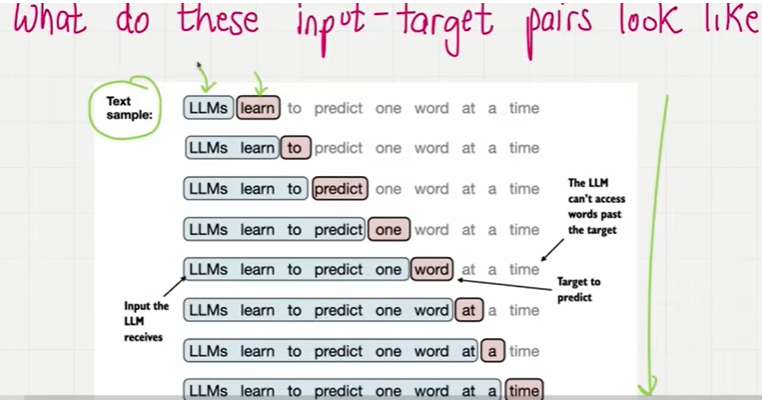

In [17]:
from datasets import load_dataset

ds = load_dataset("DarwinAnim8or/the-verdict")

text_book_list = ds['train']['text'][0:] # text data as a list
text_book_full = " ".join(text_book_list) # join all text into a single string


In [18]:
encode_book=tokenizer.encode(text_book_full)
print("number of token after BPE application",len(encode_book))

number of token after BPE application 5063


we remove first 50 token from the encoder list

so to make the context-target based on the context length which we want to provide to llm for predicting the next word


input : [1,2,3,4]
output : [2,3,4,5]

if input is 1,2 then output is 3

if input is 1,2,3 output is 4 likewise

how to decide context size ?

In [19]:
enc_sample=encode_book[50:] # remove first 50 token
context_size=4 # length of input
x=enc_sample[:context_size] # x is first 4 token input
y=enc_sample[1:context_size+1] # y is the next 4 token
print('x:',x)
print('y:     ',y,'\n target is shift by one position') #for input of  1st token output is 1st token of y

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257] 
 target is shift by one position


In [20]:
print('input target data pairs so its not 1 pair its 4 pait for 4 contextual length ')
for i in range(1,context_size+1):
  context=enc_sample[:i]
  target=enc_sample[i]
  print('context',context,'--->>',target,'target')
  print("context",tokenizer.decode(context),'--->>',tokenizer.decode([target]),"<--target")

input target data pairs so its not 1 pair its 4 pait for 4 contextual length 
context [290] --->> 4920 target
context  and --->>  established <--target
context [290, 4920] --->> 2241 target
context  and established --->>  himself <--target
context [290, 4920, 2241] --->> 287 target
context  and established himself --->>  in <--target
context [290, 4920, 2241, 287] --->> 257 target
context  and established himself in --->>  a <--target


so this task need to do effeciently in batch mode and for that we are using the **DataLoader** which makes the input and target as **pytorch** **tensor**, which can be thought as multidimentional array, **so we are converting the token id into tensor**

###implement dataloader

we will implement a data loader that fetchs input-output target pairs using sliding window apparoach


as you can see below image where for every input tensor there is 4 sub input-output operation as sliding window shift by 1 we have multiple tensor of input and corrosponding output


so for every input output pair there are 4 prediction task is there where context length increase from i= 1 to 4 word and predicting the i+1^{th} word


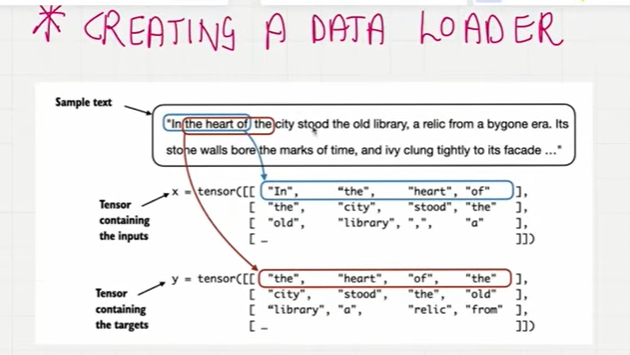

Effecient dataloader implementation

step1: tokenize entire text

step2: use sliding window into overlapping sequence

step3: return total number of row in dataset

step4: return single row from dataset

In [21]:
from torch.utils.data import Dataset, DataLoader
#### dataset can not be bunch of token data need to be input output pair

class GPTdatasetV1(Dataset):
  """the class thakes the 4 argument at initialisation text, tokenizer(bpe), max_length_context, stride==jump after making one sequence"""
  def __init__(self,txt,tokenizer,max_length_context,stride):
    #storing the input and output sequence in tensor form
    self.input_id=[]
    self.target_id=[]

    #tokenize entire text
    token_ids=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})

    #use sliding window to chunk the book into overlapping sequence of max_length_context
    for i in range(0,len(token_ids)-max_length_context,stride):
      input_ids=torch.tensor(token_ids[i:i+max_length_context])
      target_ids=torch.tensor(token_ids[i+1:i+1+max_length_context])
      self.input_id.append(input_ids)
      self.target_id.append(target_ids)

  def __len__(self):
    return len(self.input_id)

  def __getitem__(self,idx):
    """it returns context and target tesor for that id"""
    return self.input_id[idx],self.target_id[idx]

now we use GPTdatasetV1 to load the inputs in **batches via Pytorch DataLoader**

step1: initialize tokenizer

ste2: create dataset

step3:  drop_last= True **drop the last batch if its shorter than the specified batch size to prevent loss spike during training**

step4: the number of **CPU processes to use for preprocessing**

In [22]:
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  #### batch_size means number of data it process in one iteration and num_worker decides how many cpus /cpre you want to run parralelly
  #max_len for gpt its 256 awhich shows the 256 previous word and predict the next
  #initiaize tokenizer
  tokenizer=tiktoken.get_encoding("gpt2")
  #create dataset using the above function which make context-target tensor
  dataset= GPTdatasetV1(txt,tokenizer,max_length,stride)

  #create dataloader
  dataloader=DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=shuffle,
                        drop_last=drop_last,
                        num_workers=num_workers
                  )
  """so this DataLoader get the data from the getitem function of the GPTdatasetV1"""
  return dataloader

In [23]:
import torch
dataloader=create_dataloader_v1(text_book_full, batch_size=1,stride=1,max_length=4,shuffle=False)

data_iter=iter(dataloader)
first_batch=next(data_iter)
print('first_batch',first_batch)#input and output token tensors

second_batch=next(data_iter)
print('second_batch',second_batch)#input and output token tensors

first_batch [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
second_batch [tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


NOTE: input size of 4 is relatively small in real case to train LLM we need around input tensor size = 256 length



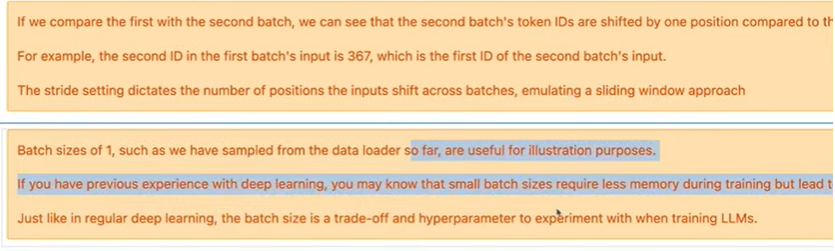

effect of batch size and stride

larger stride removes the overlaping problem between batches , as overlapping can do overfitting.

In [24]:
import torch
dataloader=create_dataloader_v1(text_book_full, batch_size=8,stride=4,max_length=4,shuffle=False)

data_iter=iter(dataloader)
first_batch=next(data_iter)
print('first_batch',first_batch)#input and output token tensors


first_batch [tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]]), tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])]


### vector embedding

In [25]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.3 MB/s eta 0:00:00


In [26]:
# import gensim.downloader as api
# model=api.load("word2vec-google-news-300")# this return the embedding for the million of word where encoding dim=300

# word_vectors=model
# #let look how the vector embedding of word look like
# # print('computer 300 dim vecotr',word_vectors['computer'])

# ## looking the famous exaple king+women-men= ?

# print('king+women-men=',word_vectors.most_similar(positive=['king','women'],negative=['men']))

# print(word_vectors.similarity('king','queen'))
# print(word_vectors.similarity('deep','learning'))
# print(word_vectors.similarity('uncle','aunty'))

# print(word_vectors.most_similar('uncle'))
# input_token_id=torch.tensor([2,3,5,1]) # we are giving everythin in tensor due to backpropogation we do

# # so for simplicuty we use vocab size of 6 and create embedding of size 3

# # using the vocab size and output dim initiate the embedding layer with random number with seed value so we can reproduce it


# vocab_size=6
# output_dim=3
"""so for simplicuty we use vocab size of 6 and create embedding of size 3

using the vocab size and output dim initiate the embedding layer with random number with seed value so we can reproduce it """
# torch.manual_seed(123)
# #initialize the mebedding matrix with random initialization for every word 3 dim embedding randomly given
# embedding_layer=torch.nn.Embedding(vocab_size,output_dim)
# embedding_layer

# so these are the weights we optimize during the LLM training to get the proper word to vec representation of word everything is in tensor
# print(embedding_layer.weight)

# #get the tensor for every word index start from 0
# embedding_layer(torch.tensor([3])) # soo for the token id 3 its embedding is
"""
so these are the weights we optimize during the LLM training to get the proper word to vec representation of word everything is in tensor
"""
# #so now we need multiple embedding for different token id
# embedding_layer(torch.tensor([1,2,3]))

checking the similarity between the words

### coding token embedding layer

converting the token id to embedding vector

##positional encoding

In [28]:
vocab_size=50257
output_dim=256
#randomlygnerate the embedding for every token
token_embedding_layer=torch.nn.Embedding(vocab_size,output_dim)

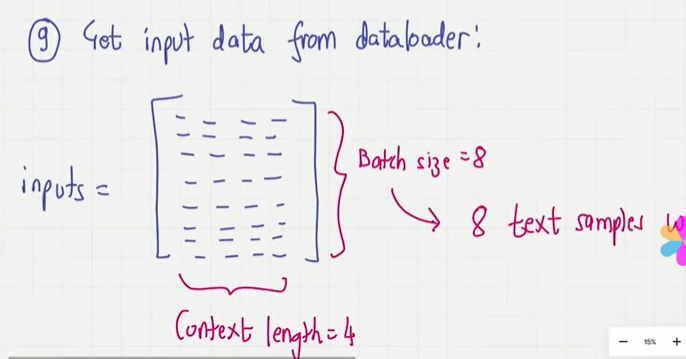

In [29]:
#now we use the DataLoaderV1 which we have made to load the data in particular batch and embedding size for training input
#so each row has 4 token id which predicts the next token id as its target value

#now we have to convet each token id of 4 to 4 embedding layer correspons to token id

#lets initialize the dataloder
max_length=4
dataloader=create_dataloader_v1(text_book_full,batch_size=8 ,max_length=max_length, stride=max_length,shuffle=False)

data_iter=iter(dataloader)
input,target=next(data_iter)

In [31]:
print("batch of input token id",input)
print("input shape",input.shape)

batch of input token id tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
input shape torch.Size([8, 4])


now we conver thes each token id into 256 embedding layer torch.nn.embedding which randoly generate embedding of 256 dim (3D vector) and

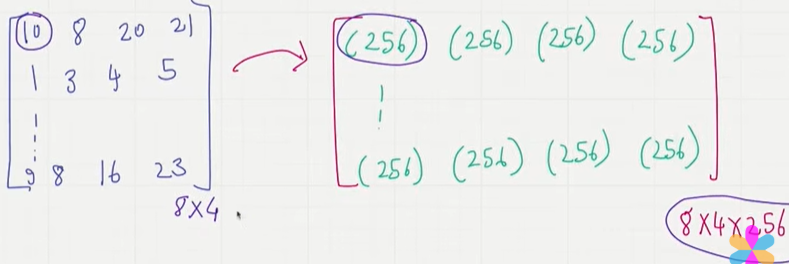

lets conver the 2d matrix to 3d matrix of dim 8 * 4 * 256

In [32]:
token_embedding=token_embedding_layer(input) # passing whole matrix in one time

token_embedding.shape


torch.Size([8, 4, 256])

now for the positional embedding we need to create another embedding layer with the same dimenssion

for one time 4 token given to predict next word processes so we need 4 positional emebdding at time

thats why its size is 4*256, where 4=number of input toekn id at time

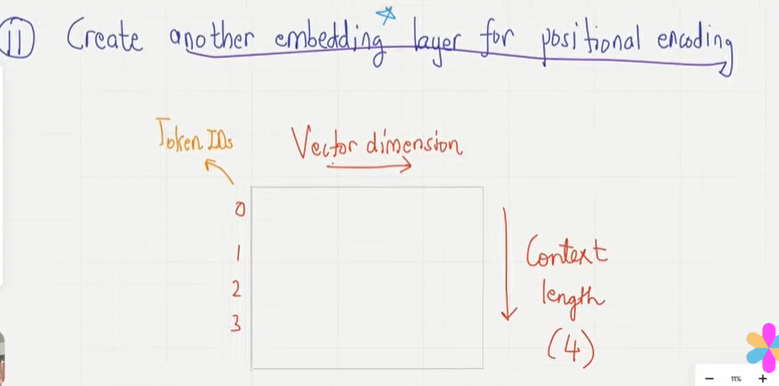

In [33]:
context_length=max_length
pos_embedding_layer=torch.nn.Embedding(context_length,output_dim)

In [ ]:
pos_embedding=pos_embedding_layer()